In [38]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset
import torch
import random

In [39]:
def normalize (volume):
    min_val = volume.min()
    max_val = volume.max()
    normalized = (volume - min_val) / (max_val - min_val)
    return normalized

In [40]:
# Load patient 001 flair
patient_path = r"C:\Users\sanja\OneDrive\Desktop\bioinformaticsprojects\brain-tumor-segmentation\data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001"
flair = nib.load(os.path.join(patient_path, "BraTS20_Training_001_flair.nii")).get_fdata()

# Apply normalize function to flair
flair_normalized = normalize(flair)

# Print the min and max BEFORE normalization
print(f"Before - min: {flair.min():.2f}, max: {flair.max():.2f}")

# Print the min and max AFTER normalization
print(f"After - min: {flair_normalized.min():.2f}, max: {flair_normalized.max():.2f}")


Before - min: 0.00, max: 625.00
After - min: 0.00, max: 1.00


(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

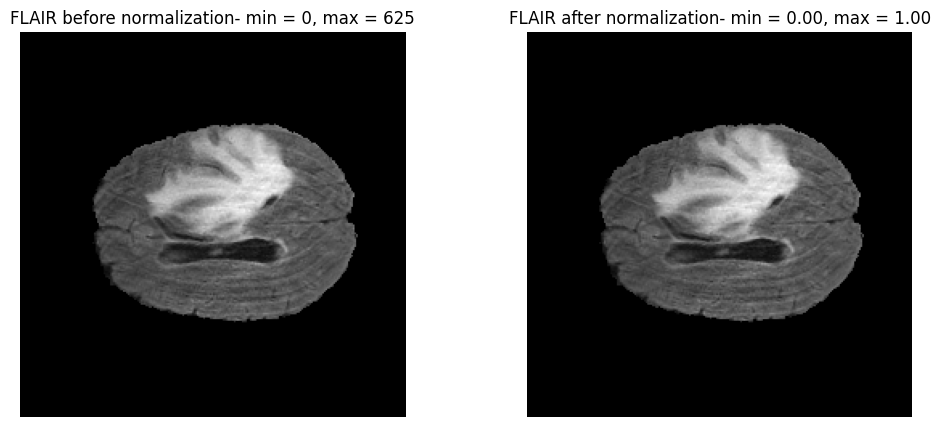

In [41]:
# slice_idx = 90
# slice_flair = flair[:, :, slice_idx]
# slice_flair_normalize = normalize(slice_flair)

slice_idx = 90
slice_flair = flair[:, :, slice_idx]
flair_normalize = normalize(flair)
slice_flair_normalize = flair_normalize[:, :, slice_idx]


fig, axes = plt.subplots(1, 2, figsize = (12,5))

# Show the FLAIR scan before normalization
axes[0].imshow(slice_flair, cmap = "gray")
axes[0].set_title(f"FLAIR before normalization- min = {flair.min():.0f}, max = {flair.max():.0f}")
axes[0].axis("off")

# Show the FLAIR scan after normalization
axes[1].imshow(slice_flair_normalize, cmap = "gray")
axes[1].set_title(f"FLAIR after normalization- min = {flair_normalize.min():.2f}, max = {flair_normalize.max():.2f}")
axes[1].axis("off")

Slicing 3D to 2D

In [42]:
# Function called get_slices that takes in a 3D volume and
# returns a list of all of its 2D slices along the third dimension.
def get_slices(volume):
    two_d=[]
    for i in range(155):
        slice_2d = volume[:, :, i]
        two_d.append(slice_2d)

    return two_d

155


(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

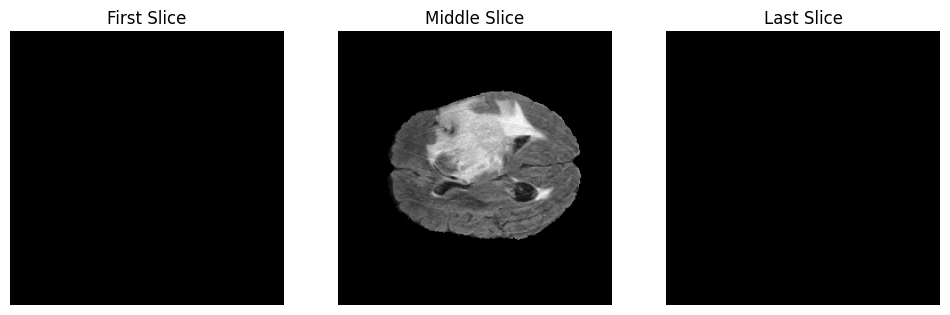

In [43]:
# Call get_slices function on normalized FLAIR volume. 
# Print how many slices you got back.
# Display the first, middle, and last slice side by side to verify it worked.

slices = get_slices(flair_normalize)
print(len(slices)) 

fig, axes = plt.subplots(1, 3, figsize = (12,5))

axes[0].imshow(slices[0], cmap = "gray")
axes[0].set_title("First Slice")
axes[0].axis("off")

axes[1].imshow(slices[77], cmap = "gray")
axes[1].set_title("Middle Slice")
axes[1].axis("off")

axes[2].imshow(slices[154], cmap = "gray")
axes[2].set_title("Last Slice")
axes[2].axis("off")